In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from utils.survival_utils import compute_best_alpha

# Display options
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ---- User configuration ----
DATA_PATH = "data_processed/survival_data_full.csv"
BASELINE_PRUNED = ['age','stage','nact','BRCA','TMB']
EXCLUDE_COLS = {"io","sites_binary","CLQ_T_F","CLQ_T_M", 'Malignant (%)','Total Cells', 'beva','parpi'}

MOLECULAR_CANDIDATES_RAW = ["EMT"]

# Candidate spatial (30 µm) features to investigate (as provided)
SPATIAL_CANDIDATES_RAW = [
'ripley_B.cell_auc_clustering',
'ripley_Endothelial_auc_clustering',
'ripley_Fibroblast_auc_clustering',
'ripley_Malignant.EMT_auc_clustering',
'ripley_Mast.cell_auc_clustering',
'ripley_Monocyte_auc_clustering',
'ripley_TNK.cell_auc_clustering',
'30um_degree_centrality_B.cell_degree_centrality',
'30um_degree_centrality_Endothelial_degree_centrality',
'30um_degree_centrality_Fibroblast_degree_centrality',
'30um_degree_centrality_Malignant.EMT_degree_centrality',
'30um_degree_centrality_Mast.cell_degree_centrality',
'30um_degree_centrality_Monocyte_degree_centrality',
'30um_degree_centrality_TNK.cell_degree_centrality',
'30um_nhood_enrichment_Malignant.EMT_B.cell',
'30um_nhood_enrichment_Malignant.EMT_Endothelial',
'30um_nhood_enrichment_Malignant.EMT_Fibroblast',
'30um_nhood_enrichment_Malignant.EMT_Mast.cell',
'30um_nhood_enrichment_Malignant.EMT_Monocyte',
'30um_nhood_enrichment_Malignant.EMT_TNK.cell',
'30um_CLQ_Malignant.EMT_B.cell',
'30um_CLQ_Malignant.EMT_Endothelial',
'30um_CLQ_Malignant.EMT_Fibroblast',
'30um_CLQ_Malignant.EMT_Mast.cell',
'30um_CLQ_Malignant.EMT_Monocyte',
'30um_CLQ_Malignant.EMT_TNK.cell',
]

# Thresholds
MAX_MISSING_FRAC = 0.40
CORR_THRESHOLD = 0.85   # treat |rho| >= 0.85 as collinear
MAX_SPATIAL_FINAL = 4   # guardrail vs 14 events
N_CV_FOLDS = 3          # due to only 14 events
IMPUTATIONS = 20        # number of imputed datasets to create
RANDOM_STATE = 42

#### The following baseline clinical features were used here:

__Clinical and treatment features__
1. _age_: age at diagnosis ($\leq 65$, $>65$) 
2. _stage_: disease stage (III or IV)
3. _nact_: treatment with Neoadjuvent chemotherapy (Treated/Untreated)


__Adnexal tumor genomic features__
1. _brca_: BRCA1/2 mutation (P/B)
2. _TMB_: tumor mutational burden (muts/kB)


__NOTE__: in the following analysis, we exclude _beva_ (treatment combination with bevacizumab (Yes/No)) and _parpi_ (traetment with PARP inhibitor (1/0)) from the primary baseline model because they are post-diagnosis treatment decisions (not baseline attributes); including them could introduce treatment-selection (confounding) and immortal time bias.

In the subsequent analysis, we also include:

__Spatiomolecular features__
1. __EMT__: proportion of EMT cells in the surveyed tissue
2. Additional metrics held in `SPATIAL_CANDIDATES_RAW` list.



In [2]:
df_raw = pd.read_csv(DATA_PATH).replace("", np.nan)
print("Raw shape:", df_raw.shape)

# Keep rows with valid survival data
assert "fu_time" in df_raw.columns and "event" in df_raw.columns, "Missing survival columns."
df = df_raw.dropna(subset=["fu_time","event"]).copy()
df["fu_time"] = pd.to_numeric(df["fu_time"], errors="coerce")
df["event"] = df["event"].astype(int)

# Exclude specified columns
for col in EXCLUDE_COLS:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Keep only baseline columns that exist
baseline_cols = [c for c in BASELINE_PRUNED if c in df.columns]

# Coerce baseline categorical variables to category
for c in baseline_cols:
    if c in ['age','stage','nact','BRCA']:
        if c in df.columns:
            df[c] = df[c].astype('category')

# Coerce numeric baseline columns
for c in baseline_cols:
    if c not in ['age','stage','nact','BRCA'] and c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Post-filter shape:", df.shape)
print("Events:", df['event'].sum(), "/ Total:", len(df))
display(df[["fu_time","event"] + baseline_cols].head(25))

Raw shape: (54, 133)
Post-filter shape: (54, 125)
Events: 14 / Total: 54


,fu_time,event,age,stage,nact,BRCA,TMB
0,1685.0,0,<=65,III,Untreated,P,6.80
1,1630.0,0,>65,IV,Untreated,B,1.58
2,1292.0,0,<=65,III,Untreated,NaN,NaN
3,3054.0,1,>65,III,Untreated,NaN,NaN
4,152.0,0,>65,III,Treated,NaN,NaN
5,2101.0,0,>65,IV,Untreated,NaN,NaN
6,1978.0,0,<=65,III,Untreated,B,6.32
7,13.0,0,<=65,NaN,Untreated,NaN,NaN
8,528.0,0,>65,IV,Treated,NaN,NaN
9,2824.0,1,<=65,III,Untreated,NaN,NaN


Inspect Baseline Missingness

In [3]:
missing_baseline = df[baseline_cols].isna().mean().sort_values(ascending=False)
print("Baseline missingness:")
display(missing_baseline.to_frame("missing_fraction"))

Baseline missingness:


,missing_fraction
BRCA,0.296296
TMB,0.296296
stage,0.037037
age,0.000000
nact,0.000000


In [4]:
# ---------------------------
# 1) Initial preprocessing
# ---------------------------
baseline_df = df[baseline_cols].copy()

# Transform TMP
# add small eps to avoid log(0): use log(TMB + 0.0001)
baseline_df['TMB_log'] = np.log(baseline_df['TMB'].astype(float).fillna(np.nan) + 0.01)

# Cap categorical to codes for imputation (keep mapping)
maps = {}

# age: "<=65", ">65"
maps['age'] = {'<=65': 0, '>65': 1}
baseline_df['age_code'] = baseline_df['age'].map(maps['age'])

# stage: III, IV
maps['stage'] = {'III': 3, 'IV': 4}
baseline_df['stage_code'] = baseline_df['stage'].map(maps['stage'])

# nact: Treated / Untreated
maps['nact'] = {'Untreated': 0, 'Treated': 1}
baseline_df['nact_code'] = baseline_df['nact'].map(maps['nact'])

# brca: P/B (pathogenic/benign?) map to 0/1; keep NaNs
maps['brca'] = {'B': 0, 'P': 1}
baseline_df['brca_code'] = baseline_df['BRCA'].map(maps['brca'])

# Survival columns
# assume fu_time in days and event is 0/1
baseline_df['duration'] = df['fu_time']
baseline_df['event'] = df['event'].astype(int)

# Choose columns to impute (numeric codes and TMB_log)
imp_cols = ['age_code','stage_code','nact_code','brca_code','TMB_log']

In [5]:
# We'll perform multiple imputations by repeating with different random_state.
m = IMPUTATIONS

imputed_datasets = []

for i in range(m):

    print(f"Imputation {i+1}/{m}...")

    imp = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=100,
        tol=1e-3,
        sample_posterior=True,
        random_state=RANDOM_STATE + i,
        initial_strategy='median',
        skip_complete=True
    )

    imputed_array = imp.fit_transform(baseline_df[imp_cols])
    imputed_df = baseline_df.copy()
    # place imputed values back
    for j, col in enumerate(imp_cols):
        imputed_df[col] = imputed_array[:, j]

    # Post-process: clip and round categorical codes appropriately
    # For binary flags, clip to valid range then round to nearest 0/1
    # order: age, stage, nact, brca, tmb_log
    imputed_df['age_code'] = np.clip(imputed_df['age_code'], 0, 1).round().astype(int)
    imputed_df['stage_code'] = np.clip(imputed_df['stage_code'], 3, 4).round().astype(int)
    imputed_df['nact_code'] = np.clip(imputed_df['nact_code'], 0, 1).round().astype(int)
    imputed_df['brca_code'] = np.clip(imputed_df['brca_code'], 0, 1).round().astype(int)
    # TMB_log is continuous, so no clipping needed


    # revert codes to readable categories
    imputed_df['age_imputed'] = imputed_df['age_code'].map({0: '<=65', 1: '>65'})
    imputed_df['stage_imputed'] = imputed_df['stage_code'].map({3: 'III', 4: 'IV'})
    imputed_df['nact_imputed'] = imputed_df['nact_code'].map({0: 'Untreated', 1: 'Treated'})
    imputed_df['brca_imputed'] = imputed_df['brca_code'].map({0:'B',1:'P'})

    imputed_datasets.append(imputed_df)

Imputation 1/20...
Imputation 2/20...
Imputation 3/20...
Imputation 4/20...
Imputation 5/20...
Imputation 6/20...
Imputation 7/20...
Imputation 8/20...
Imputation 9/20...
Imputation 10/20...
Imputation 11/20...
Imputation 12/20...
Imputation 13/20...
Imputation 14/20...
Imputation 15/20...
Imputation 16/20...
Imputation 17/20...
Imputation 18/20...
Imputation 19/20...
Imputation 20/20...


Bootstrap evaluation on imputation 1/20...
Bootstrap evaluation on imputation 2/20...
Bootstrap evaluation on imputation 3/20...
Bootstrap evaluation on imputation 4/20...
Bootstrap evaluation on imputation 5/20...
Bootstrap evaluation on imputation 6/20...
Bootstrap evaluation on imputation 7/20...
Bootstrap evaluation on imputation 8/20...
Bootstrap evaluation on imputation 9/20...
Bootstrap evaluation on imputation 10/20...
Bootstrap evaluation on imputation 11/20...
Error during C-index calculation: Data has no comparable pairs, cannot estimate concordance index.
Skipping this bootstrap.
Bootstrap evaluation on imputation 12/20...
Bootstrap evaluation on imputation 13/20...
Bootstrap evaluation on imputation 14/20...
Bootstrap evaluation on imputation 15/20...
Bootstrap evaluation on imputation 16/20...
Bootstrap evaluation on imputation 17/20...
Bootstrap evaluation on imputation 18/20...
Bootstrap evaluation on imputation 19/20...
Bootstrap evaluation on imputation 20/20...
Boots

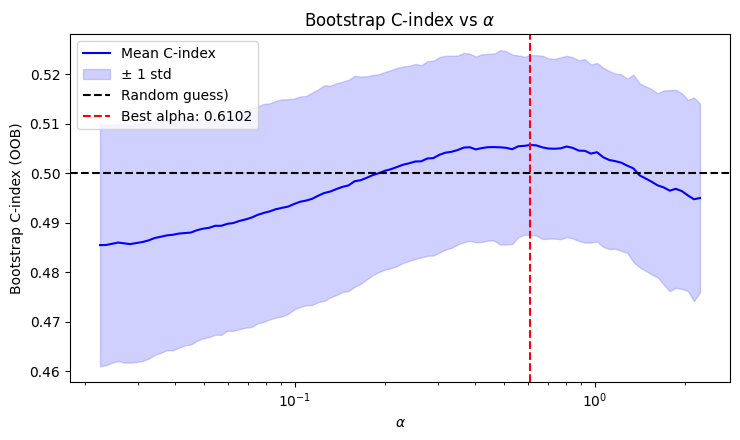

In [9]:
# Fit a penalized Cox model (Elastic-Net) and compute the optimized penalty via OOB C-index

from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis

covariates = ['age_code','stage_code','nact_code','brca_code','TMB_log']

l1_ratio = 0.05
alpha_min_ratio = 0.01
max_iter = 2000
random_state = RANDOM_STATE
n_bootstrap = 200
n_alpha = 100

best_alpha, mean_cindex = compute_best_alpha(imputed_datasets, covariates, l1_ratio=l1_ratio, alpha_min_ratio=alpha_min_ratio, max_iter=max_iter, n_bootstrap=n_bootstrap, n_alpha=n_alpha, random_state=random_state, plotting=True)

# Output: Best alpha: 0.4616 with mean C-index: 0.507

Note: The poor performance here is expected, since these are OOB estimations.

In [10]:
# Now that we know alpha, we can refit the model on each imputed dataset and get the coefficients.
# We can then summarize the coefficients across imputations.
# Also compute the apparent C-index on the full data for reference.

coef_list = []
hr_per_sd_list = []
hr_per_unit_list = []
cindex_app_list = []

binary_vars = ['age_code','stage_code','nact_code','brca_code']  # 0/1 (stage_code is 3/4 originally but coded; treat as numeric diff=1 after coding)
continuous_vars = ['TMB_log']

for imputed_dataset in imputed_datasets:
    X_raw_df = imputed_dataset[covariates].astype(float)
    scaler_full = StandardScaler().fit(X_raw_df.values)
    X_std = scaler_full.transform(X_raw_df.values)

    y = Surv.from_arrays(
        event=imputed_dataset['event'].astype(bool),
        time=imputed_dataset['duration'].astype(float)
    )

    model = CoxnetSurvivalAnalysis(l1_ratio=0.05, alphas=[best_alpha], max_iter=2000)
    model.fit(X_std, y)

    coef_std = pd.Series(model.coef_.ravel(), index=covariates)        # β on standardized scale
    coef_list.append(coef_std)

    # HR per 1 SD increase
    hr_per_sd = np.exp(coef_std)
    hr_per_sd_list.append(hr_per_sd)

    # Convert to original scale: β_orig = β_std / scale
    scale = pd.Series(scaler_full.scale_, index=covariates)
    coef_orig = coef_std / scale

    # HR per 1 original unit (for binaries: 0→1)
    hr_per_unit = np.exp(coef_orig)
    hr_per_unit_list.append(hr_per_unit)

    # Apparent C-index
    risk_app = model.predict(X_std)
    ci_app = concordance_index_censored(y['event'], y['time'], risk_app)[0]
    cindex_app_list.append(ci_app)

MEAN_BASELINE_C_INDEX = np.mean(cindex_app_list)
STD_BASELINE_C_INDEX = np.std(cindex_app_list)

print(f"Apparent C-index across imputations: {MEAN_BASELINE_C_INDEX:.3f} ± {STD_BASELINE_C_INDEX:.3f} (m={len(cindex_app_list)})")

coef_df_std = pd.DataFrame(coef_list)
hr_sd_df = pd.DataFrame(hr_per_sd_list)          # per SD increase
hr_unit_df = pd.DataFrame(hr_per_unit_list)      # per original unit (0→1 for binaries)

print("\nStandardized coefficients (β on z-scales) summary:")
print(coef_df_std.describe())

print("\nHR per 1 SD increase summary:")
print(hr_sd_df.describe())

print("\nHR per 1 original unit (binary 0 -> 1; continuous per raw unit) summary:")
print(hr_unit_df.describe())

# Optional: split summaries
print("\nBinary variables (0 -> 1) HR (original scale) medians:")
print(hr_unit_df[binary_vars].median().to_frame("HR_median"))

print("\nContinuous variables HR per 1 raw unit (consider reporting per meaningful increment):")
print(hr_unit_df[continuous_vars].median().to_frame("HR_median"))

Apparent C-index across imputations: 0.670 ± 0.017 (m=20)

Standardized coefficients (β on z-scales) summary:
        age_code  stage_code  nact_code  brca_code    TMB_log
count  20.000000   20.000000  20.000000  20.000000  20.000000
mean    0.093738   -0.041058   0.000080  -0.037965  -0.021833
std     0.003190    0.008386   0.000233   0.042416   0.036498
min     0.087085   -0.066041   0.000000  -0.148536  -0.110838
25%     0.091426   -0.041033   0.000000  -0.056379  -0.042224
50%     0.094176   -0.039928   0.000000  -0.028277  -0.012211
75%     0.096196   -0.037328   0.000000   0.000000   0.000000
max     0.098528   -0.029651   0.000970   0.000000   0.051453

HR per 1 SD increase summary:
        age_code  stage_code  nact_code  brca_code    TMB_log
count  20.000000   20.000000  20.000000  20.000000  20.000000
mean    1.098277    0.959806   1.000080   0.963556   0.979019
std     0.003500    0.007985   0.000233   0.039807   0.035394
min     1.090990    0.936092   1.000000   0.861969   

#### EMT Effect
___
We can now investigate the effect of the EMT proportion on survival outcomes.
Is this going to improve things or not?

In [63]:
covariates = ['age_code','stage_code','nact_code','brca_code','TMB_log', "EMT"]

l1_ratio = 0.05
alpha_min_ratio = 0.01
max_iter = 2000
random_state = RANDOM_STATE
n_bootstrap = 200
n_alpha = 100

# add the EMT column to each imputed dataset
imputed_datasets_with_emt = []
for imputed_dataset in imputed_datasets:
    imputed_dataset_with_emt = imputed_dataset.copy()
    imputed_dataset_with_emt["EMT"] =  df_raw["EMT"]
    imputed_datasets_with_emt.append(imputed_dataset_with_emt)

In [64]:
# We can also report some additional metrics here, let's see what we can do.

# Now that we know alpha, we can refit the model on each imputed dataset and get the coefficients.
# We can then summarize the coefficients across imputations.
# Also compute the apparent C-index on the full data for reference.

coef_list = []
hr_per_sd_list = []
hr_per_unit_list = []
cindex_app_list = []

binary_vars = ['age_code','stage_code','nact_code','brca_code']  # 0/1 (stage_code is 3/4 originally but coded; treat as numeric diff=1 after coding)
continuous_vars = ['TMB_log', 'EMT']

for imputed_dataset in imputed_datasets_with_emt:
    
    X_raw_df = imputed_dataset[covariates].astype(float)
    scaler_full = StandardScaler().fit(X_raw_df.values)
    X_std = scaler_full.transform(X_raw_df.values)

    y = Surv.from_arrays(
        event=imputed_dataset['event'].astype(bool),
        time=imputed_dataset['duration'].astype(float)
    )

    model = CoxnetSurvivalAnalysis(l1_ratio=0.05, alphas=[best_alpha], max_iter=2000)
    model.fit(X_std, y)

    coef_std = pd.Series(model.coef_.ravel(), index=covariates) # β on standardized scale
    coef_list.append(coef_std)

    # HR per 1 SD increase
    hr_per_sd = np.exp(coef_std)
    hr_per_sd_list.append(hr_per_sd)

    # Convert to original scale: β_orig = β_std / scale
    scale = pd.Series(scaler_full.scale_, index=covariates)
    coef_orig = coef_std / scale

    # HR per 1 original unit (for binaries: 0→1)
    hr_per_unit = np.exp(coef_orig)
    hr_per_unit_list.append(hr_per_unit)

    # Apparent C-index
    risk_app = model.predict(X_std)
    ci_app = concordance_index_censored(y['event'], y['time'], risk_app)[0]
    cindex_app_list.append(ci_app)

MEAN_EMT_C_INDEX = np.mean(cindex_app_list)
STD_EMT_C_INDEX = np.std(cindex_app_list)

print(f"Apparent C-index across imputations: {MEAN_EMT_C_INDEX:.3f} ± {STD_EMT_C_INDEX:.3f} (m={len(cindex_app_list)})")

coef_df_std = pd.DataFrame(coef_list)
hr_sd_df = pd.DataFrame(hr_per_sd_list)          # per SD increase
hr_unit_df = pd.DataFrame(hr_per_unit_list)      # per original unit (0→1 for binaries)

print("\nStandardized coefficients (β on z-scales) summary:")
print(coef_df_std.describe())

print("\nHR per 1 SD increase summary:")
print(hr_sd_df.describe())

print("\nHR per 1 original unit (binary 0→1; continuous per raw unit) summary:")
print(hr_unit_df.describe())

# Optional: split summaries
print("\nBinary variables (0→1) HR (original scale) medians:")
print(hr_unit_df[binary_vars].median().to_frame("HR_median"))

print("\nContinuous variables HR per 1 raw unit (consider reporting per meaningful increment):")
print(hr_unit_df[continuous_vars].median().to_frame("HR_median"))


Apparent C-index across imputations: 0.713 ± 0.015 (m=20)

Standardized coefficients (β on z-scales) summary:
        age_code  stage_code  nact_code  brca_code    TMB_log        EMT
count  20.000000   20.000000       20.0  20.000000  20.000000  20.000000
mean    0.095578   -0.045083        0.0  -0.035522  -0.021216   0.095908
std     0.003038    0.008428        0.0   0.041388   0.035057   0.002894
min     0.089345   -0.069847        0.0  -0.144605  -0.110703   0.085449
25%     0.093503   -0.045031        0.0  -0.053140  -0.041260   0.095428
50%     0.096082   -0.043995        0.0  -0.024923  -0.008765   0.096717
75%     0.097984   -0.041231        0.0   0.000000   0.000000   0.097659
max     0.099940   -0.033069        0.0   0.000000   0.047158   0.098271

HR per 1 SD increase summary:
        age_code  stage_code  nact_code  brca_code    TMB_log        EMT
count  20.000000   20.000000       20.0  20.000000  20.000000  20.000000
mean    1.100300    0.955950        1.0   0.965873   0.9

In [61]:
np.abs((0.670 - 0.713)/ 0.670 * 100)

np.float64(6.417910447761183)

__NOTE__: here we can see a slight improvement in C-index when the EMT proportion is also added to the feature set.

### Exploring the spatial features
_____



In [13]:
df_raw[SPATIAL_CANDIDATES_RAW].head(15)

,ripley_B.cell_auc_clustering,ripley_Endothelial_auc_clustering,ripley_Fibroblast_auc_clustering,ripley_Malignant.EMT_auc_clustering,ripley_Mast.cell_auc_clustering,ripley_Monocyte_auc_clustering,ripley_TNK.cell_auc_clustering,30um_degree_centrality_B.cell_degree_centrality,30um_degree_centrality_Endothelial_degree_centrality,30um_degree_centrality_Fibroblast_degree_centrality,30um_degree_centrality_Malignant.EMT_degree_centrality,30um_degree_centrality_Mast.cell_degree_centrality,30um_degree_centrality_Monocyte_degree_centrality,30um_degree_centrality_TNK.cell_degree_centrality,30um_nhood_enrichment_Malignant.EMT_B.cell,30um_nhood_enrichment_Malignant.EMT_Endothelial,30um_nhood_enrichment_Malignant.EMT_Fibroblast,30um_nhood_enrichment_Malignant.EMT_Mast.cell,30um_nhood_enrichment_Malignant.EMT_Monocyte,30um_nhood_enrichment_Malignant.EMT_TNK.cell,30um_CLQ_Malignant.EMT_B.cell,30um_CLQ_Malignant.EMT_Endothelial,30um_CLQ_Malignant.EMT_Fibroblast,30um_CLQ_Malignant.EMT_Mast.cell,30um_CLQ_Malignant.EMT_Monocyte,30um_CLQ_Malignant.EMT_TNK.cell
0,66213.459789,89539.363282,5.597913e+05,1.623359e+05,2799.213258,244425.006411,2.204155e+05,0.172392,0.239303,0.294684,0.156243,0.009456,0.657682,0.487816,-6.667674,-5.357143,-19.732373,-1.821514,-4.084628,-4.010396,7.431805,14.436783,4.145842,NaN,21.875877,21.164162
1,12810.109725,47662.786991,5.530302e+05,1.477714e+05,NaN,400918.105391,9.164731e+04,0.037811,0.161769,0.742277,0.146299,NaN,0.711808,0.376343,-3.553668,-4.032922,-7.608154,NaN,-5.975378,-4.879598,2.269651,21.515576,27.058251,NaN,29.298426,25.955193
2,NaN,87371.571071,7.208792e+05,1.653043e+06,4515.782959,220730.274612,8.993052e+04,NaN,0.148830,0.491671,0.688210,0.014723,0.569593,0.193850,NaN,-18.315557,-41.198073,-3.567774,-10.792932,-10.471834,NaN,12.612768,11.244372,NaN,23.459724,5.562950
3,0.000000,35998.806102,2.788378e+05,3.023701e+05,NaN,66719.322915,2.109970e+04,0.001465,0.095511,0.111502,0.260247,NaN,0.258437,0.116283,-1.516739,-7.281914,-24.022465,NaN,-2.831720,-2.727180,NaN,8.999176,3.727729,NaN,24.622746,19.641059
4,472808.526419,127933.839952,3.752551e+05,1.583876e+04,5449.646331,740042.717921,3.949359e+05,0.242781,0.288725,0.497751,0.029863,0.022911,0.728448,0.649266,-0.854038,-0.356674,0.928077,-0.454116,3.389017,2.508989,NaN,NaN,NaN,NaN,NaN,NaN
5,124153.296967,113519.346746,8.707868e+05,4.739448e+04,1682.669288,159806.074249,7.242479e+04,0.258415,0.134050,0.364529,0.039366,0.007865,0.408011,0.187259,-4.065502,-4.701391,-6.831676,-1.028956,-4.408314,-3.473678,0.000000,4.709676,18.123149,NaN,10.924183,0.000000
6,86914.157825,76707.313936,1.347651e+06,1.376459e+06,931.964020,208624.218395,1.035901e+05,0.156660,0.112596,0.570079,0.481165,0.003812,0.422610,0.227149,-6.846451,-17.748397,-50.619442,-2.628786,-11.413964,-10.192261,3.878556,3.059844,6.112188,NaN,11.606174,5.503092
7,0.000000,87221.754995,2.443277e+05,2.455999e+06,NaN,96582.403410,1.249323e+05,0.004288,0.371161,0.420754,0.880013,NaN,0.455819,0.310872,-1.460104,-17.889513,-39.837802,NaN,-18.666160,-31.065060,NaN,29.484802,26.943686,NaN,31.557200,21.672324
8,321864.986696,357270.771261,7.555022e+05,1.595155e+05,13334.567941,586874.554192,1.293555e+06,0.622705,0.568483,0.853007,0.179972,0.050802,0.821673,0.878001,-5.319613,-4.233972,-1.549498,-2.378884,-2.212244,-6.908263,9.457983,11.947852,17.480676,NaN,16.372281,11.807181
9,11027.918868,52150.802308,8.665275e+04,6.384413e+05,8764.196073,319275.576897,2.086849e+05,0.040319,0.242346,0.249863,0.408144,0.048478,0.734602,0.588695,-5.349126,-3.987644,-8.976587,-2.777471,-10.766207,-8.763489,NaN,19.904779,15.663545,13.008153,20.776857,21.205596


In [20]:
# Correlation filtering
# Create a working copy with median imputation (just for correlation)
corr_df = df_raw[SPATIAL_CANDIDATES_RAW].copy()
for c in corr_df.columns:
    corr_df[c] = corr_df[c].fillna(corr_df[c].median())

spearman_corr = corr_df.corr(method='spearman')

# List high-correlation pairs
CORR_THRESHOLD = 0.85
pairs = []
for i, c1 in enumerate(spearman_corr.columns):
    for j, c2 in enumerate(spearman_corr.columns):
        if j <= i: 
            continue
        r = spearman_corr.loc[c1, c2]
        if abs(r) >= CORR_THRESHOLD:
            pairs.append((c1, c2, r))

print(f"High-correlation pairs (|rho| ≥ {CORR_THRESHOLD}): {len(pairs)}")
for tup in pairs[:25]:
    print(f"{tup[0]}  <->  {tup[1]}  |  rho={tup[2]:.3f}")
if len(pairs) > 25:
    print("... truncated")

High-correlation pairs (|rho| ≥ 0.85): 4
ripley_B.cell_auc_clustering  <->  30um_degree_centrality_B.cell_degree_centrality  |  rho=0.973
ripley_Fibroblast_auc_clustering  <->  30um_degree_centrality_Fibroblast_degree_centrality  |  rho=0.852
ripley_Malignant.EMT_auc_clustering  <->  30um_degree_centrality_Malignant.EMT_degree_centrality  |  rho=0.952
ripley_TNK.cell_auc_clustering  <->  30um_degree_centrality_TNK.cell_degree_centrality  |  rho=0.879


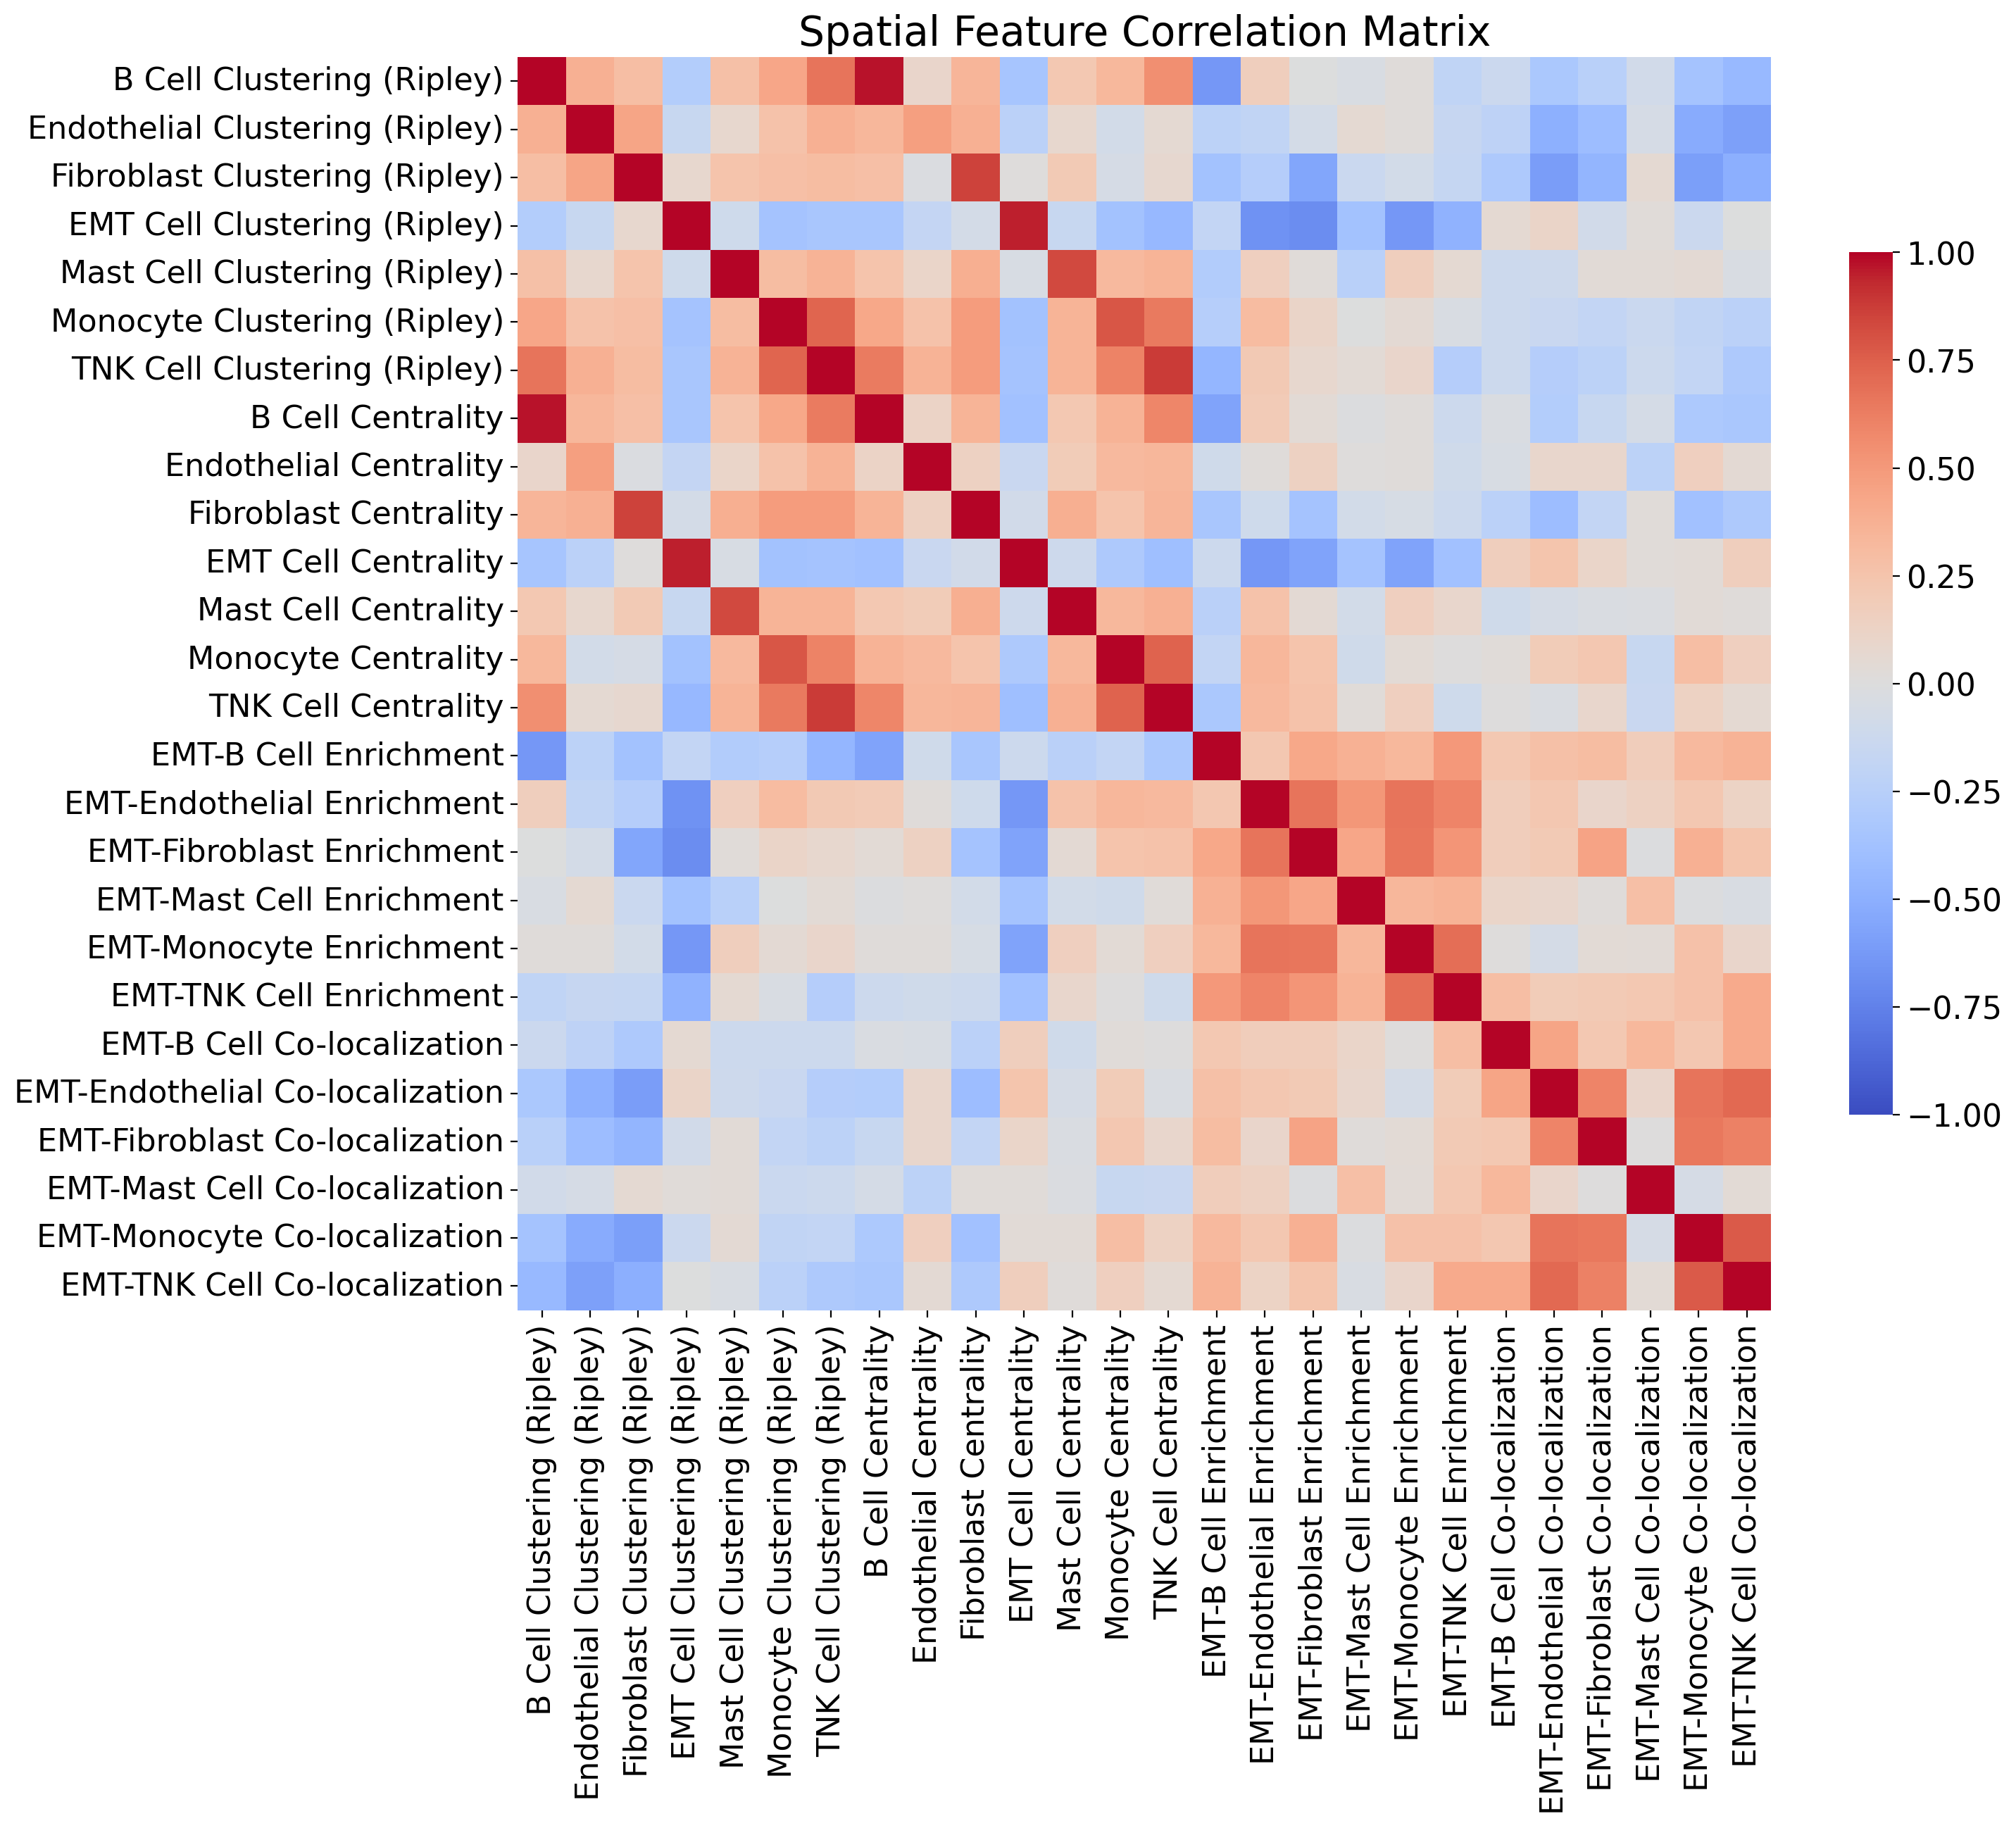

In [22]:
# Rename the features, ready for publication
rename_map = {
# Ripley's clustering metrics
'ripley_B.cell_auc_clustering': 'B Cell Clustering (Ripley)',
'ripley_Endothelial_auc_clustering': 'Endothelial Clustering (Ripley)',
'ripley_Fibroblast_auc_clustering': 'Fibroblast Clustering (Ripley)',
'ripley_Malignant.EMT_auc_clustering': 'EMT Cell Clustering (Ripley)',
'ripley_Mast.cell_auc_clustering': 'Mast Cell Clustering (Ripley)',
'ripley_Monocyte_auc_clustering': 'Monocyte Clustering (Ripley)',
'ripley_TNK.cell_auc_clustering': 'TNK Cell Clustering (Ripley)',

# Degree centrality metrics (30μm)
'30um_degree_centrality_B.cell_degree_centrality': 'B Cell Centrality',
'30um_degree_centrality_Endothelial_degree_centrality': 'Endothelial Centrality',
'30um_degree_centrality_Fibroblast_degree_centrality': 'Fibroblast Centrality',
'30um_degree_centrality_Malignant.EMT_degree_centrality': 'EMT Cell Centrality',
'30um_degree_centrality_Mast.cell_degree_centrality': 'Mast Cell Centrality',
'30um_degree_centrality_Monocyte_degree_centrality': 'Monocyte Centrality',
'30um_degree_centrality_TNK.cell_degree_centrality': 'TNK Cell Centrality',

# Neighborhood enrichment metrics
'30um_nhood_enrichment_Malignant.EMT_B.cell': 'EMT-B Cell Enrichment',
'30um_nhood_enrichment_Malignant.EMT_Endothelial': 'EMT-Endothelial Enrichment',
'30um_nhood_enrichment_Malignant.EMT_Fibroblast': 'EMT-Fibroblast Enrichment',
'30um_nhood_enrichment_Malignant.EMT_Mast.cell': 'EMT-Mast Cell Enrichment',
'30um_nhood_enrichment_Malignant.EMT_Monocyte': 'EMT-Monocyte Enrichment',
'30um_nhood_enrichment_Malignant.EMT_TNK.cell': 'EMT-TNK Cell Enrichment',

# Co-localization quotient (CLQ) metrics
'30um_CLQ_Malignant.EMT_B.cell': 'EMT-B Cell Co-localization',
'30um_CLQ_Malignant.EMT_Endothelial': 'EMT-Endothelial Co-localization',
'30um_CLQ_Malignant.EMT_Fibroblast': 'EMT-Fibroblast Co-localization',
'30um_CLQ_Malignant.EMT_Mast.cell': 'EMT-Mast Cell Co-localization',
'30um_CLQ_Malignant.EMT_Monocyte': 'EMT-Monocyte Co-localization',
'30um_CLQ_Malignant.EMT_TNK.cell': 'EMT-TNK Cell Co-localization',
}

# create a copy and apply the mapping
spearman_corr_copy = spearman_corr.rename(columns=rename_map, index=rename_map)

plt.figure(figsize=(0.5*len(spearman_corr_copy.columns)+2, 0.5*len(spearman_corr_copy.columns)+2), dpi = 200)
sns.heatmap(spearman_corr_copy, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.5},  vmin=-1, vmax=1)
plt.tick_params(axis='both', which='major', labelsize=16)

cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

plt.title("Spatial Feature Correlation Matrix", fontsize = 21)
plt.tight_layout()
plt.show()

In [23]:
# NOTE: it might be good to remove some centrality metrics in this case.
# Prune collinear spatial features (|rho| >= CORR_THRESHOLD)
drop_cols = set()

for c1, c2, r in pairs:
    # Prefer dropping degree_centrality if present in the pair
    if "degree_centrality" in c1 and "degree_centrality" not in c2:
        drop_cols.add(c1)
    elif "degree_centrality" in c2 and "degree_centrality" not in c1:
        drop_cols.add(c2)
    else:
        # Fallback: drop the one with higher missingness (tie -> drop c2)
        miss = df_raw[[c1, c2]].isna().mean()
        to_drop = c1 if miss[c1] > miss[c2] else c2
        drop_cols.add(to_drop)

print(f"Dropping {len(drop_cols)} collinear features:", sorted(drop_cols))

# Build the filtered candidate list
SPATIAL_CANDIDATES_FILTERED = [c for c in SPATIAL_CANDIDATES_RAW if c not in drop_cols]
print(f"Remaining spatial candidates: {len(SPATIAL_CANDIDATES_FILTERED)}")

Dropping 4 collinear features: ['30um_degree_centrality_B.cell_degree_centrality', '30um_degree_centrality_Fibroblast_degree_centrality', '30um_degree_centrality_Malignant.EMT_degree_centrality', '30um_degree_centrality_TNK.cell_degree_centrality']
Remaining spatial candidates: 22


In [24]:
# 1) collect spatial features available and filter by missingness
spatial_cols_all = [c for c in SPATIAL_CANDIDATES_FILTERED if c in df.columns]
miss_frac = df[spatial_cols_all].isna().mean().sort_values()
spatial_keep = miss_frac[miss_frac <= MAX_MISSING_FRAC].index.tolist()
print(f"Spatial candidates kept (<= {MAX_MISSING_FRAC:.0%} missing): {len(spatial_keep)} of {len(spatial_cols_all)}")

excluded = [c for c in spatial_cols_all if c not in spatial_keep]
print("Excluded due to missingness:", excluded)

# NOTE: we still have some NaNs in the spatial features
# Here, we will fill NaNs with the median value for that feature.
imp = SimpleImputer(strategy="median")
X_sp_imp = imp.fit_transform(df[spatial_keep])
X_sp_df = pd.DataFrame(X_sp_imp, columns=spatial_keep, index=df.index)

Spatial candidates kept (<= 40% missing): 20 of 22
Excluded due to missingness: ['30um_CLQ_Malignant.EMT_B.cell', '30um_CLQ_Malignant.EMT_Mast.cell']


In [25]:
# Investigation of additional spatial metrics added one by one to the baseline model
# NOTE: Here we use the same baseline alpha penalty strength.

# Evaluate each spatial feature added to baseline with elastic net; aggregate C-index across imputations

C_index_df = pd.DataFrame()           # per-feature C-index per imputation
coef_df = pd.DataFrame()      # per-feature coefficient (last column) per imputation

for idx_feat, spatial_feature in  enumerate(X_sp_df.columns):

    print(f"Evaluating spatial feature {idx_feat+1}/{len(X_sp_df.columns)}: {spatial_feature}")

    C_index_imputation = []
    coef_imputation = []

    # add the EMT comlumn to the imputed dataset + the spatial feature
    covariates = ['age_code','stage_code','nact_code','brca_code','TMB_log', 'EMT']
    covariates.append(spatial_feature)

    # imputed_datasets_spatial = []
    for imputed_dataset in imputed_datasets:
        # add the EMT column to each imputed dataset
        imputed_dataset_spatial = imputed_dataset.copy()
        imputed_dataset_spatial["EMT"] = df_raw["EMT"]
        imputed_dataset_spatial[spatial_feature] = X_sp_df[spatial_feature]
        # imputed_datasets_spatial.append(imputed_dataset_spatial)
    
        X_new = imputed_dataset_spatial[covariates].astype(float).to_numpy()
        scaler_new = StandardScaler().fit(X_new)
        X_new = scaler_new.transform(X_new)

        y = Surv.from_arrays(
            event=imputed_dataset_spatial['event'].astype(bool),
            time=imputed_dataset_spatial['duration'].astype(float)
        )
        # Refit at chosen alpha and compute apparent C-index
        model = CoxnetSurvivalAnalysis(l1_ratio=l1_ratio, alphas=[best_alpha], max_iter=max_iter)
        model.fit(X_new, y)

        risk = model.predict(X_new)
        ci_app = concordance_index_censored(y['event'], y['time'], risk)[0]
        C_index_imputation.append(ci_app)

        # Save spatial coefficient (last column corresponds to this spatial feature)
        coef_last = float(model.coef_.ravel()[-1])
        coef_imputation.append(coef_last)

    # collect per-feature results
    C_index_df = pd.concat([C_index_df, pd.Series(C_index_imputation, name=spatial_feature)], axis=1)
    coef_df = pd.concat([coef_df, pd.Series(coef_imputation, name=spatial_feature)], axis=1)

# Summaries across imputations
C_index_summary = pd.DataFrame({
    "mean_ci": C_index_df.mean(axis=0),
    "std_ci": C_index_df.std(axis=0),
})
coef_summary = pd.DataFrame({
    "nonzero_rate": (coef_df != 0).mean(axis=0),
    "mean_coef": coef_df.mean(axis=0),
    "mean_HR": np.exp(coef_df.mean(axis=0)),
})

results = C_index_summary.join(coef_summary).sort_values("mean_ci", ascending=False)
display(results)

# NOTE: The C-index for the baseline model without EMT was 0.670 ± 0.017 (m=20)
# NOTE: The C-index for the model including EMT was 0.713 ± 0.015 (m=20)
# So we can see that some spatial features can improve the C-index further.

Evaluating spatial feature 1/20: ripley_Endothelial_auc_clustering
Evaluating spatial feature 2/20: ripley_Fibroblast_auc_clustering
Evaluating spatial feature 3/20: ripley_Malignant.EMT_auc_clustering
Evaluating spatial feature 4/20: ripley_Monocyte_auc_clustering
Evaluating spatial feature 5/20: ripley_TNK.cell_auc_clustering
Evaluating spatial feature 6/20: 30um_degree_centrality_Endothelial_degree_centrality
Evaluating spatial feature 7/20: 30um_degree_centrality_Monocyte_degree_centrality
Evaluating spatial feature 8/20: 30um_nhood_enrichment_Malignant.EMT_Endothelial
Evaluating spatial feature 9/20: 30um_nhood_enrichment_Malignant.EMT_Fibroblast
Evaluating spatial feature 10/20: 30um_nhood_enrichment_Malignant.EMT_TNK.cell
Evaluating spatial feature 11/20: 30um_nhood_enrichment_Malignant.EMT_Monocyte
Evaluating spatial feature 12/20: 30um_CLQ_Malignant.EMT_Endothelial
Evaluating spatial feature 13/20: 30um_CLQ_Malignant.EMT_Monocyte
Evaluating spatial feature 14/20: 30um_CLQ_Mali

,mean_ci,std_ci,nonzero_rate,mean_coef,mean_HR
30um_degree_centrality_Monocyte_degree_centrality,0.771053,0.013489,1.00,-0.168645,0.844809
ripley_Monocyte_auc_clustering,0.761357,0.012033,1.00,-0.173400,0.840802
30um_degree_centrality_Mast.cell_degree_centrality,0.742798,0.012814,1.00,-0.129703,0.878356
ripley_TNK.cell_auc_clustering,0.734626,0.014508,1.00,-0.125592,0.881975
ripley_Mast.cell_auc_clustering,0.731440,0.013131,1.00,-0.145253,0.864804
30um_CLQ_Malignant.EMT_Monocyte,0.718006,0.013011,1.00,-0.009106,0.990936
30um_nhood_enrichment_Malignant.EMT_Mast.cell,0.714543,0.011314,1.00,-0.009075,0.990966
30um_nhood_enrichment_Malignant.EMT_Endothelial,0.714127,0.009663,1.00,-0.068292,0.933988
30um_CLQ_Malignant.EMT_TNK.cell,0.712742,0.015015,0.05,0.000039,1.000039
30um_nhood_enrichment_Malignant.EMT_TNK.cell,0.712742,0.015015,0.00,0.000000,1.000000


### The aggregate model
_____

__NOTE__: For the aggregate model, we will only consider the features that showsed a positive C-index improvement, relative to the model which included the baseline clinical features + EMT proportions. In addition, only the stable features (nonzero_rate = 1.0) are included.

In [26]:
TOP_SPATIAL_FEATURES = results.loc[(results["mean_ci"] > MEAN_EMT_C_INDEX) & (results["nonzero_rate"] > 0.9)].index.tolist()
TOP_SPATIAL_FEATURES


['30um_degree_centrality_Monocyte_degree_centrality',
 'ripley_Monocyte_auc_clustering',
 '30um_degree_centrality_Mast.cell_degree_centrality',
 'ripley_TNK.cell_auc_clustering',
 'ripley_Mast.cell_auc_clustering',
 '30um_CLQ_Malignant.EMT_Monocyte',
 '30um_nhood_enrichment_Malignant.EMT_Mast.cell',
 '30um_nhood_enrichment_Malignant.EMT_Endothelial']

In [27]:
print(f"Building final model with {len(TOP_SPATIAL_FEATURES)} top spatial features")

# Build final model with baseline + EMT + top spatial features
final_covariates = ['age_code','stage_code','nact_code','brca_code','TMB_log', 'EMT'] + TOP_SPATIAL_FEATURES

final_coef_list = []
final_hr_per_sd_list = []  
final_hr_per_unit_list = []
final_cindex_app_list = []

binary_vars = ['age_code','stage_code','nact_code','brca_code']
continuous_vars = ['TMB_log', 'EMT'] + TOP_SPATIAL_FEATURES

for imputed_dataset in imputed_datasets:
    # Prepare dataset with all features
    imputed_dataset_final = imputed_dataset.copy()
    imputed_dataset_final["EMT"] = df_raw["EMT"]
    
    # Add spatial features with proper index alignment
    for spatial_feature in TOP_SPATIAL_FEATURES:
        imputed_dataset_final[spatial_feature] = X_sp_df[spatial_feature].reindex(imputed_dataset_final.index)
    
    # Prepare features and standardize
    X_final = imputed_dataset_final[final_covariates].astype(float)
    scaler_final = StandardScaler().fit(X_final.values)
    X_final_std = scaler_final.transform(X_final.values)
    
    # Prepare survival outcome
    y = Surv.from_arrays(
        event=imputed_dataset_final['event'].astype(bool),
        time=imputed_dataset_final['duration'].astype(float)
    )
    
    # Fit final model
    final_model = CoxnetSurvivalAnalysis(l1_ratio=l1_ratio, alphas=[best_alpha], max_iter=max_iter)
    final_model.fit(X_final_std, y)
    
    # Extract coefficients
    coef_std = pd.Series(final_model.coef_.ravel(), index=final_covariates)
    final_coef_list.append(coef_std)
    
    # HR per 1 SD increase  
    hr_per_sd = np.exp(coef_std)
    final_hr_per_sd_list.append(hr_per_sd)
    
    # Convert to original scale for HR per unit
    scale = pd.Series(scaler_final.scale_, index=final_covariates)
    coef_orig = coef_std / scale
    hr_per_unit = np.exp(coef_orig)
    final_hr_per_unit_list.append(hr_per_unit)
    
    # Apparent C-index
    risk_final = final_model.predict(X_final_std)
    ci_final = concordance_index_censored(y['event'], y['time'], risk_final)[0]
    final_cindex_app_list.append(ci_final)

MEAN_SPATIAL_C_INDEX = np.mean(final_cindex_app_list)
STD_SPATIAL_C_INDEX = np.std(final_cindex_app_list)

# Summarize final model performance
print(f"\nFinal Model Performance:")
print(f"C-index: {MEAN_SPATIAL_C_INDEX:.3f} ± {STD_SPATIAL_C_INDEX:.3f}")

# Create comprehensive results table
final_coef_df = pd.DataFrame(final_coef_list)
final_hr_sd_df = pd.DataFrame(final_hr_per_sd_list)
final_hr_unit_df = pd.DataFrame(final_hr_per_unit_list)

# Summary statistics for final model
final_results = pd.DataFrame({
    'mean_coef_std': final_coef_df.mean(),
    'std_coef_std': final_coef_df.std(), 
    'mean_HR_per_SD': final_hr_sd_df.mean(),
    'HR_per_SD_95CI_lower': final_hr_sd_df.quantile(0.025),
    'HR_per_SD_95CI_upper': final_hr_sd_df.quantile(0.975),
    'mean_HR_per_unit': final_hr_unit_df.mean(),
    'HR_per_unit_95CI_lower': final_hr_unit_df.quantile(0.025),
    'HR_per_unit_95CI_upper': final_hr_unit_df.quantile(0.975),
    'nonzero_rate': (final_coef_df != 0).mean()
})

print("\nFinal Model Coefficients and Hazard Ratios:")
display(final_results.round(3))

Building final model with 8 top spatial features

Final Model Performance:
C-index: 0.774 ± 0.007

Final Model Coefficients and Hazard Ratios:


,mean_coef_std,std_coef_std,mean_HR_per_SD,HR_per_SD_95CI_lower,HR_per_SD_95CI_upper,mean_HR_per_unit,HR_per_unit_95CI_lower,HR_per_unit_95CI_upper,nonzero_rate
age_code,0.095,0.003,1.099,1.092,1.103,1.211,1.195,1.220,1.00
stage_code,-0.053,0.010,0.948,0.923,0.958,0.879,0.826,0.901,1.00
nact_code,0.022,0.002,1.022,1.019,1.025,1.045,1.039,1.052,1.00
brca_code,-0.039,0.036,0.962,0.886,1.000,0.925,0.782,1.000,0.90
TMB_log,-0.019,0.027,0.982,0.921,1.003,0.985,0.940,1.003,0.55
EMT,0.069,0.002,1.072,1.066,1.075,1.003,1.003,1.003,1.00
30um_degree_centrality_Monocyte_degree_centrality,-0.106,0.001,0.899,0.898,0.902,0.610,0.605,0.618,1.00
ripley_Monocyte_auc_clustering,-0.114,0.002,0.892,0.889,0.896,1.000,1.000,1.000,1.00
30um_degree_centrality_Mast.cell_degree_centrality,-0.070,0.002,0.932,0.929,0.934,0.055,0.047,0.060,1.00
ripley_TNK.cell_auc_clustering,-0.056,0.003,0.946,0.942,0.953,1.000,1.000,1.000,1.00


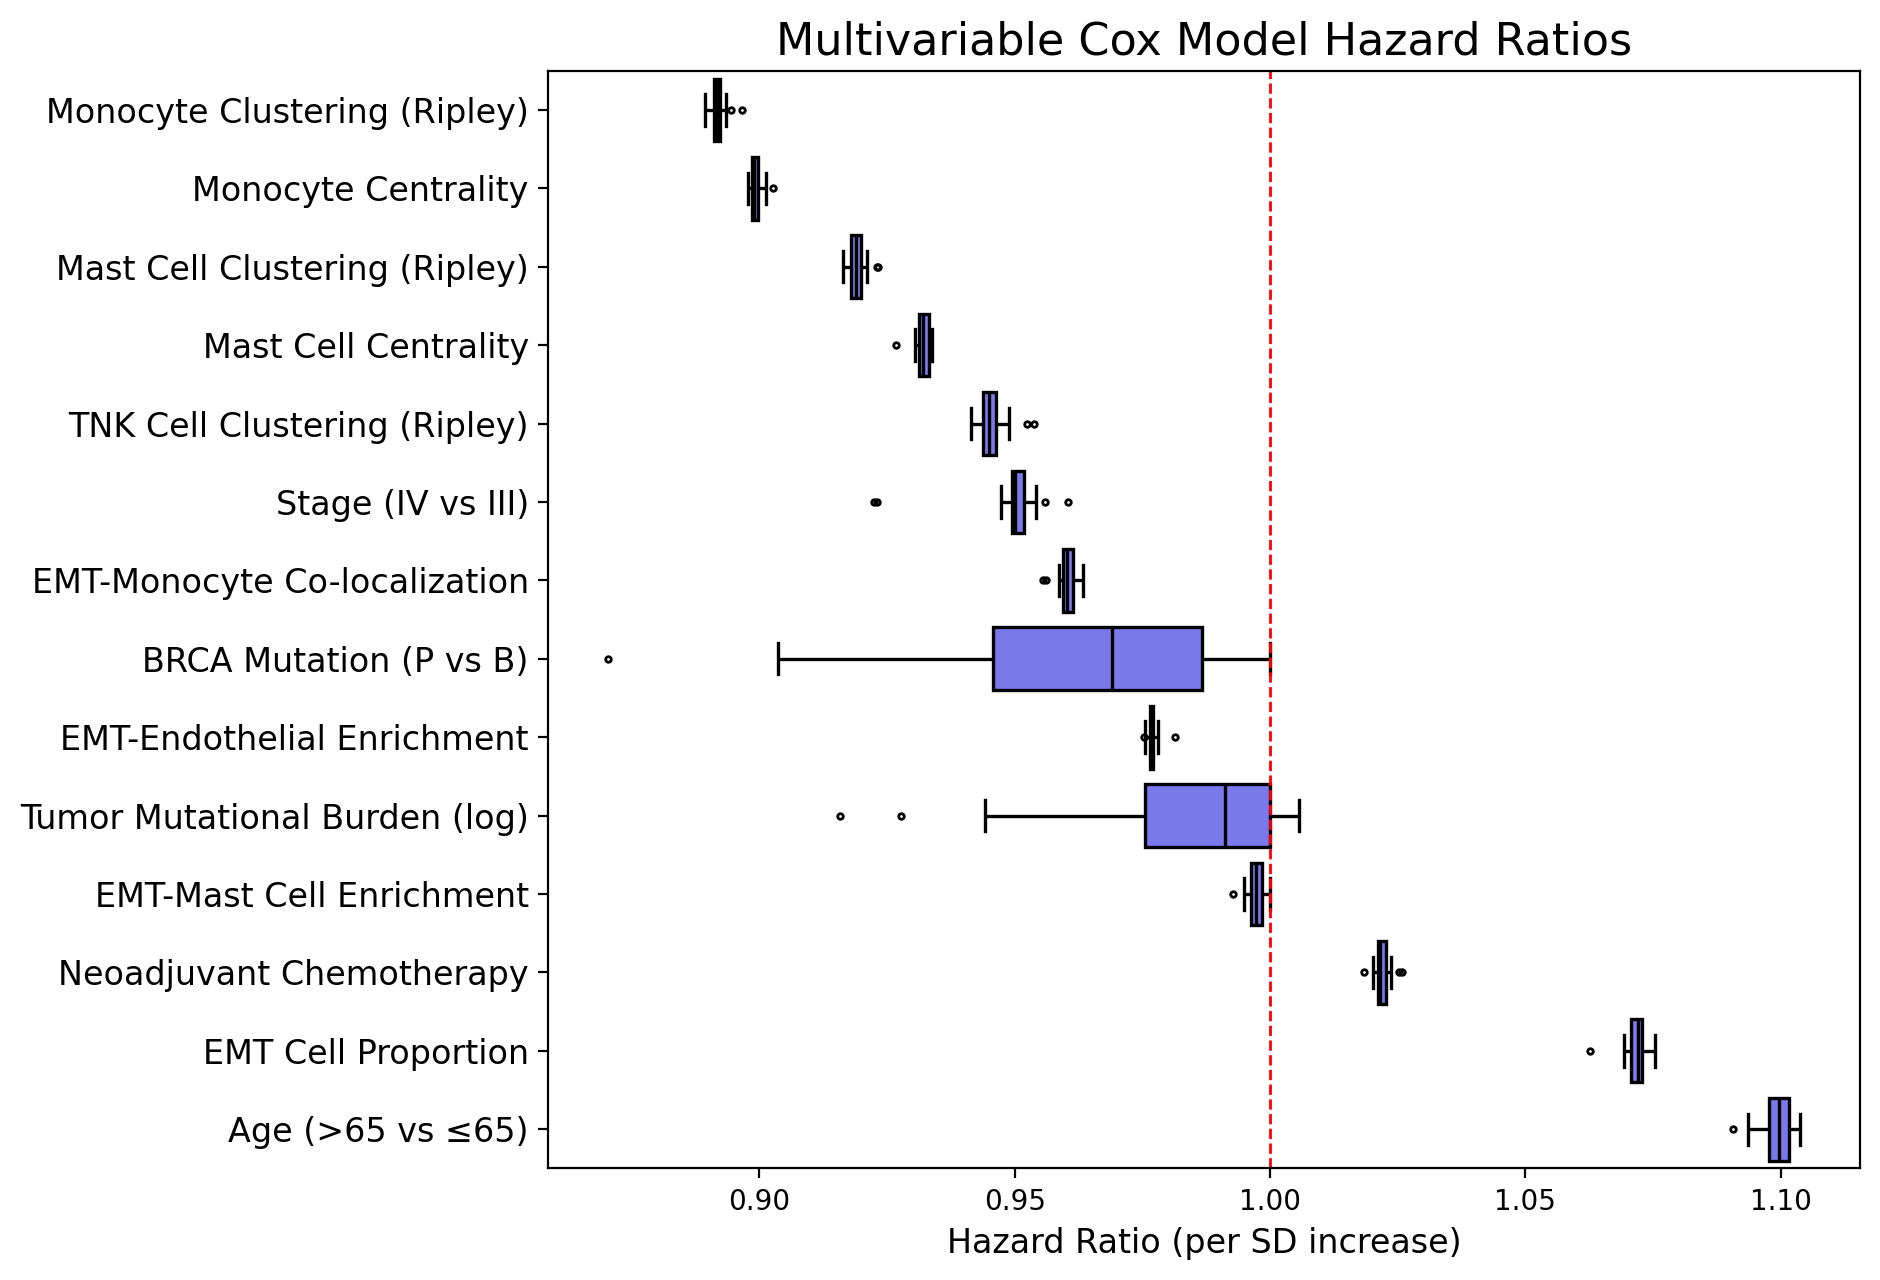

In [52]:
# Plot of hazard rations

# Mapping for final model features - publication ready
final_feature_rename_map = {
    # Clinical and genomic features
    'age_code': 'Age (>65 vs ≤65)',
    'stage_code': 'Stage (IV vs III)',
    'nact_code': 'Neoadjuvant Chemotherapy',
    'brca_code': 'BRCA Mutation (P vs B)',
    'TMB_log': 'Tumor Mutational Burden (log)',
    'EMT': 'EMT Cell Proportion',
    
    # Spatial features - organized by metric type
    '30um_degree_centrality_Monocyte_degree_centrality': 'Monocyte Centrality',
    'ripley_Monocyte_auc_clustering': 'Monocyte Clustering (Ripley)',
    '30um_degree_centrality_Mast.cell_degree_centrality': 'Mast Cell Centrality',
    'ripley_TNK.cell_auc_clustering': 'TNK Cell Clustering (Ripley)',
    'ripley_Mast.cell_auc_clustering': 'Mast Cell Clustering (Ripley)',
    '30um_CLQ_Malignant.EMT_Monocyte': 'EMT-Monocyte Co-localization',
    '30um_nhood_enrichment_Malignant.EMT_Mast.cell': 'EMT-Mast Cell Enrichment',
    '30um_nhood_enrichment_Malignant.EMT_Endothelial': 'EMT-Endothelial Enrichment'
}

# Apply the mapping to your HR plot DataFrame
final_hr_sd_df_renamed = final_hr_sd_df.rename(columns=final_feature_rename_map)


df_plot = final_hr_sd_df_renamed.copy()  # replace with your DataFrame if different
long_df = df_plot.melt(var_name="feature", value_name="value")

order = df_plot.median().sort_values().index  # order features by median

plt.figure(figsize=(9.5, 6.5), dpi = 200)
ax = sns.boxplot(
    data=long_df, y="feature", x="value", order=order, orient="h",
    color="#6666FF", fliersize=2, linewidth=1.2, linecolor='k'
)

plt.axvline(1.0, color="red", linestyle="--", linewidth=1)  # HR=1 reference
plt.xlabel("Hazard Ratio (per SD increase)", fontsize=12)
plt.tick_params(axis='y', which='major', labelsize=12)
plt.ylabel("")
plt.title("Multivariable Cox Model Hazard Ratios", fontsize = 16)
plt.tight_layout()
plt.show()

In [68]:
description_df = final_hr_sd_df.describe().T
# order by mean column
description_df = description_df.loc[description_df.sort_values('mean', ascending=False).index]
description_df["mean"]

age_code                                              1.099159
EMT                                                   1.071566
nact_code                                             1.021968
30um_nhood_enrichment_Malignant.EMT_Mast.cell         0.997231
TMB_log                                               0.981625
30um_nhood_enrichment_Malignant.EMT_Endothelial       0.976977
brca_code                                             0.962058
30um_CLQ_Malignant.EMT_Monocyte                       0.960218
stage_code                                            0.948422
ripley_TNK.cell_auc_clustering                        0.945695
30um_degree_centrality_Mast.cell_degree_centrality    0.931945
ripley_Mast.cell_auc_clustering                       0.919158
30um_degree_centrality_Monocyte_degree_centrality     0.899262
ripley_Monocyte_auc_clustering                        0.891884
Name: mean, dtype: float64

#### EMT stratification
____




Stratified analysis shape: (54, 4)
Log-rank test statistic: 4.110054788419941
p-value: 0.04262898144121771
       counts  observed  expected  statistic
group                                       
High       27         8  4.554499   3.445501
Low        27         6  9.445501  -3.445501


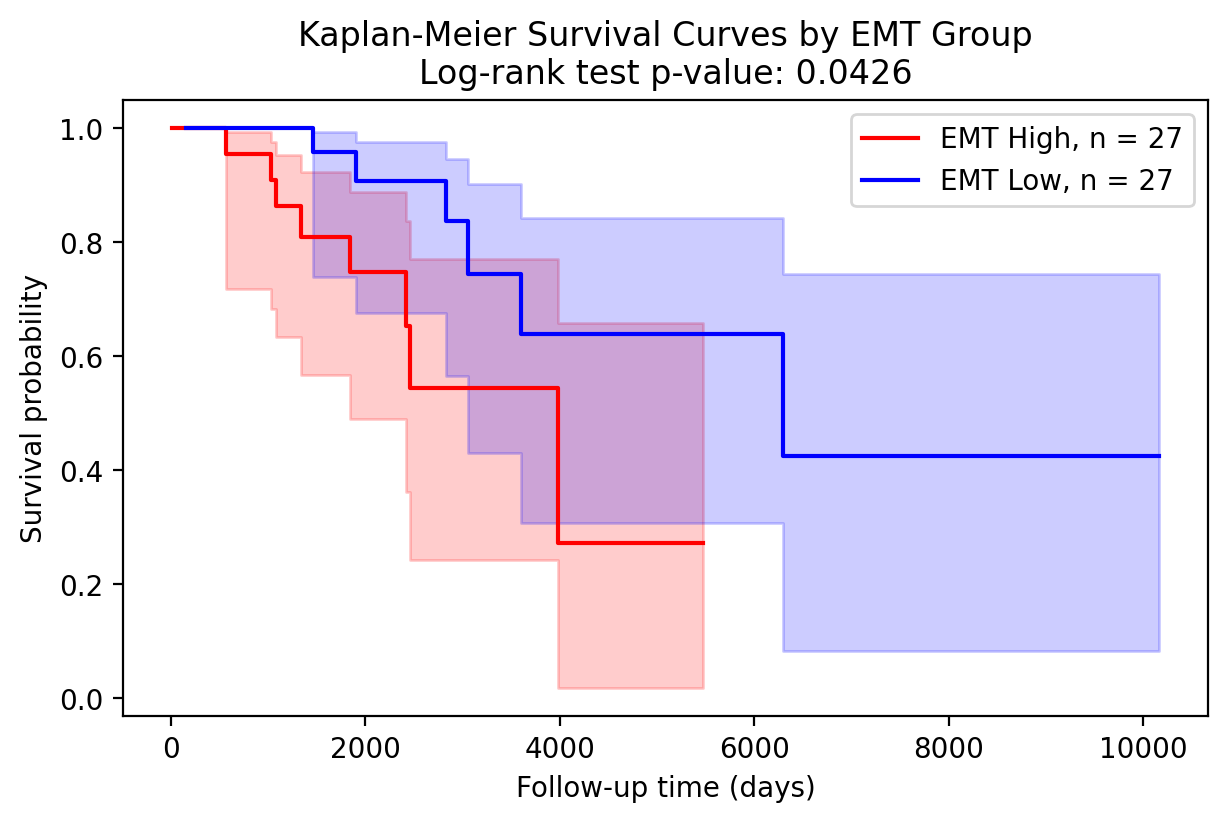

In [59]:
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival

# Median split
stratified_df = df_raw[["Patient_ID", "fu_time", "event", "EMT"]].copy()
# drop rows with missing EMT
stratified_df = stratified_df.dropna(subset=["EMT"])

print("Stratified analysis shape:", stratified_df.shape)
median_emt  = stratified_df["EMT"].median()
stratified_df["EMT_group"] = np.where(stratified_df["EMT"] >= median_emt, "High", "Low")

# Build the survival object
y_statified = Surv.from_arrays(
    event = stratified_df["event"].astype(bool),
    time = stratified_df["fu_time"].astype(float)
)

X_stratified = stratified_df.drop(columns=["Patient_ID", "event", "fu_time"])

# Kaplan-Meier curves

fig, ax = plt.subplots(figsize = (7, 4), dpi = 200)

for group in ["High", "Low"]:
    mask = X_stratified["EMT_group"] == group
    time, survival_prob, conf_int = kaplan_meier_estimator(y_statified["event"][mask], y_statified["time"][mask], conf_type="log-log")

    if group == "High":
        color = "red"
    else:
        color = "blue"

    ax.step(time, survival_prob, where="post", label=f"EMT {group}, n = {mask.sum()}", color=color)
    ax.fill_between(time, conf_int[0], conf_int[1], step="post", alpha=0.2, color=color)

# compare_survival expects: (y, group_indicator)
chisq, pvalue, stats, covariance = compare_survival(
    y_statified,
    X_stratified["EMT_group"],
    return_stats=True
)

print("Log-rank test statistic:", chisq)
print("p-value:", pvalue)
print(stats)

ax.set_xlabel("Follow-up time (days)", fontsize = 10)
ax.set_ylabel("Survival probability", fontsize = 10)
ax.set_title(f"Kaplan-Meier Survival Curves by EMT Group\nLog-rank test p-value: {pvalue:.4f}", fontsize = 12)
ax.legend(fontsize = 10)
plt.show()